In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FuncFormatter
import collections

In [4]:
folder = "./data/bitstream_surrogate/"
file_name1 = "bitstream_closed_loop_1.txt"
file_name2 = "bitstream_closed_loop_2.txt"

In [6]:
# file_name = "openloop_bits_2_4_25.txt"
# bitstream = data_read_hex(folder+file_name)
# # bitstream = data_read_bin(folder+file_name1) + data_read_bin(folder+file_name2)
# # find the probabilty of bits
# find_Prob(bitstream)
# with open("bitstream_2_4_25.txt", "w") as f:
#     f.write(bitstream)

In [5]:
def data_read_hex(file_path):
    with open(file_path, 'r') as f:
        data_hex = f.read()

    data_bin = [bin(int(h, 16))[2:] for h in data_hex.split("\n")]
    bitstream = "".join(data_bin)
    return bitstream

def data_read_bin(file_path):
    with open(file_path, 'r') as f:
        bitstream = f.read()
    return bitstream

def plot_probability_bias(probabilities):
    probabilities = np.array(probabilities)
    num_positions = len(probabilities)
    indices = np.arange(num_positions)
    
    # Calculate the probability of '0'
    prob_of_zero = 1.0 - probabilities

    plt.figure(figsize=(8, 4))
    
    # 1. Plot the P('0') (bottom segment)
    plt.bar(indices, prob_of_zero, color='lightcoral', alpha=0.7, label="P('0')")
    
    # 2. Plot the P('1') (top segment), starting where P('0') ends (stacking)
    plt.bar(indices, probabilities, bottom=prob_of_zero, color='navy', alpha=0.7, label="P('1')")
    
    # Add a horizontal line at the ideal probability (0.5)
    # plt.axhline(0.5, color='black', linestyle='--', label='Ideal Probability (0.5)')
    
    # Customize the plot
    plt.title('Bitwise Probability Distribution Check (Stacked $P(0) + P(1) = 1$)')
    plt.xlabel('Bit Position Index', fontsize=12)
    plt.ylabel("Probability", fontsize=12)
    
    # Set y-limit to show the full probability range from 0 to 1
    plt.ylim(0, 1) 

    # Set x-ticks to correspond to the indices 0 to N-1
    plt.xticks(indices)
    
    plt.grid(axis='y', linestyle='dotted', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def calculate_normalized_autocorrelation(data_array, max_lag=20):
    """
    Calculates the normalized autocorrelation function (ACF) of a 1D sequence.
    
    The autocorrelation at lag k, R(k), measures the correlation between the 
    sequence and itself shifted by k positions.
    
    Args:
        data_array (np.ndarray): The numerical input sequence (e.g., [0, 1, 0, 1]).
        max_lag (int): The maximum lag k to calculate the correlation for.

    Returns:
        tuple: (lags, acf_values)
    """
    n = len(data_array)    
    # 1. Center the data: subtract the mean
    x = data_array - np.mean(data_array)
    # 2. Use numpy.correlate to get the non-normalized autocorrelation
    # 'full' mode returns the cross-correlation for all possible overlaps
    raw_acf = np.correlate(x, x, mode='full')
    
    # 3. Extract the right half of the result, representing non-negative lags (k >= 0)
    # The result has length 2n - 1, and the center (lag 0) is at index n - 1
    normalized_acf = raw_acf[n - 1:]
    
    # 4. Normalize by the variance (raw_acf[n-1] is the variance * n)
    # The normalization factor is the raw_acf at lag 0 (the variance of the full sequence)
    normalized_acf /= normalized_acf[0]
    
    # 5. Trim to the requested max_lag
    lags = np.arange(max_lag + 1)
    acf_values = normalized_acf[:max_lag + 1]
    
    return lags, acf_values

def plot_autocorrelation_check(bitstream, max_lag=20):
    """
    Performs the autocorrelation test on a bit stream and plots the Correlogram.
    
    Args:
        bitstream (str): The input bit sequence string (e.g., "1011001...").
        max_lag (int): The maximum lag to show on the plot.
    """
    if not bitstream:
        print("Error: Input bit stream is empty.")
        return

    # 1. Convert bitstream string to a NumPy array of integers (0 and 1)
    data_array = np.array([int(b) for b in bitstream if b in ('0', '1')])
    
    if len(data_array) < max_lag:
        print(f"Warning: Stream length ({len(data_array)}) is too short for max_lag ({max_lag}). Using max_lag = {len(data_array) // 2}.")
        max_lag = len(data_array) // 2

    lags, acf_values = calculate_normalized_autocorrelation(data_array, max_lag)
    
    # 2. Calculate Statistical Significance Boundaries (95% Confidence Interval)
    # For large sample sizes N, the standard error for autocorrelation is approx 1/sqrt(N)
    # The 95% confidence bounds are at +/- 1.96 * (1/sqrt(N))
    n = len(data_array)
    confidence_bound = 1.96 / np.sqrt(n) 

    # Format x-ticks for 'k' notation (e.g., 5k, 10k)
    def format_k(x, pos):
        if x == 0:
            return '0'
        return f'{int(x/1000)}k'

    plt.figure(figsize=(8, 4))

    # Plot the ACF values as a scatter plot (dots) to handle high density
    plt.scatter(lags[1:], acf_values[1:], s=2, color='skyblue', label='Autocorrelation ($k > 0$)')

    # Add the significance boundaries as horizontal dashed lines
    plt.axhline(0, color='gray', linestyle='-', zorder=0) # zorder=0 keeps it behind the dots
    plt.axhline(confidence_bound, color='red', linestyle='--', label=f'95% Confidence Bound ($\pm$ {confidence_bound:.4f})')
    plt.axhline(-confidence_bound, color='red', linestyle='--')

    # Customize the plot appearance
    plt.title(f'Autocorrelation Check (Correlogram) for Bit Stream (N={len(bitstream)})')
    plt.xlabel('Lag Length', fontsize=12) # Matching image label
    plt.ylabel('ACF', fontsize=12)        # Matching image label

    ax = plt.gca()
    ax.xaxis.set_major_formatter(FuncFormatter(format_k))

    # Set y-limit to match the image scale (e.g., -0.002 to 0.002)
    # plt.ylim(min(-0.2, -1.1 * confidence_bound), max(0.2, 1.1 * confidence_bound))
    plt.ylim(-0.02, 0.02)
    tick_interval = max_lag // 4
    plt.xticks(np.arange(0, max_lag + 1, tick_interval))
    plt.grid(axis='y', linestyle='dotted', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def calculate_max_group_occurrences(bitstream, group_lengths):
    """
    For various group lengths, calculates the maximum number of times any single 
    unique bit group occurs in the stream.
    
    Returns:
        tuple: (group_lengths_used, max_counts)
    """
    max_counts = []
    
    for L in group_lengths:
        # Ensure the stream is long enough for at least one group
        if len(bitstream) < L:
            continue
            
        # 1. Divide the stream into groups of length L
        # We only consider full, non-overlapping groups
        groups = [bitstream[i:i+L] for i in range(0, len(bitstream) // L * L, L)]
        
        if not groups:
            max_counts.append(0)
            continue

        # 2. Count the frequency of each unique group
        counts = collections.Counter(groups)
        
        # 3. Find the maximum count
        max_count = max(counts.values()) if counts else 0
        max_counts.append(max_count)
        
    # Filter group_lengths based on what was actually processed and had a count > 0
    valid_lengths = [L for L, count in zip(group_lengths, max_counts) if count > 0]
    valid_counts = [count for count in max_counts if count > 0]
    
    return valid_lengths, valid_counts

def plot_max_bit_group_occurrences(bitstream, group_lengths):
    """
    Calculates and plots the maximum occurrence count of any single bit group 
    against the group length on a logarithmic scale, matching the image provided.
    """
    lengths, max_counts = calculate_max_group_occurrences(bitstream, group_lengths)

    if not lengths:
        print("Could not calculate group occurrences. Check bitstream length.")
        return

    plt.figure(figsize=(8, 4))
    
    # Create the bar chart
    # Use a narrow width and set color/edge to match the provided image style
    bars = plt.bar(lengths, max_counts, width=4, color='darkorange', edgecolor='black', alpha=0.9)
    
    # Set Y-axis to logarithmic scale
    plt.yscale('log')
    
    # Customizing the plot
    plt.title('Measured Maximum Occurrences of Bit-Group', fontsize=14)
    plt.xlabel('Bit-group length (bit)', fontsize=12)
    plt.ylabel('Max counts', fontsize=12)
    
    # Set X-ticks to the group lengths checked
    plt.xticks(lengths, [str(l) for l in lengths], fontsize=12)
    
    # Set Y-axis ticks for log scale
    max_val = max(max_counts)
    log_ticks = [10**i for i in range(int(np.log10(max_val)) + 1)]
    if 1 not in log_ticks: log_ticks.insert(0, 1)
    
    plt.yticks(log_ticks)
    
    # Add labels on top of the bars
    for bar, count in zip(bars, max_counts):
        yval = bar.get_height()
        # Position the text label slightly above the bar on the log scale
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.1, 
                 str(count), 
                 ha='center', 
                 va='bottom',
                 fontsize=10)

    plt.grid(axis='y', linestyle='dotted', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_3d_transition_matrix(pre_groups, post_groups):
    # 1. Setup and Transition Matrix Calculation (Same as 2D)
    group_len = len(pre_groups[0])
    num_states = 2**group_len
    transition_matrix = np.zeros((num_states, num_states), dtype=int)
    labels = [format(i, f'0{group_len}b') for i in range(num_states)]
    
    for pre, post in zip(pre_groups, post_groups):
        pre_index = int(pre, 2)
        post_index = int(post, 2)
        transition_matrix[pre_index, post_index] += 1
    
    
    # Create a meshgrid for the X (Pre) and Y (Post) coordinates
    x_indices = np.arange(num_states)
    y_indices = np.arange(num_states)
    X, Y = np.meshgrid(x_indices, y_indices)
    
    # Flatten the data for the 3D plot function (matching X, Y, and Z counts)
    X_flat = X.flatten()
    Y_flat = Y.flatten()
    
    # Z_flat is the height (transition count)
    Z_flat = transition_matrix.T.flatten() # Transpose (.T) is often needed to align X/Y axes correctly in mplot3d
    
    # Bar properties for the plot
    dx = dy = 0.5  # Bar width in X and Y directions
    dz = Z_flat    # Bar height
    zpos = np.zeros_like(Z_flat) # Starting Z position (0)

    # 3. Plot the 3D Bars
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.bar3d(X_flat, Y_flat, zpos, dx, dy, dz, color='skyblue', alpha=0.8)

    # 4. Set Labels and Title
    ax.set_title(f'3D Transition Frequency (4-Bit Groups) ', pad=20)
    ax.set_xlabel('Previous Group ($G_i$) Index', labelpad=15)
    ax.set_ylabel('Subsequent Group ($G_{i+1}$) Index', labelpad=15)
    ax.set_zlabel('Transition Count', labelpad=15)

    ax.set_xticks(x_indices)
    ax.set_yticks(y_indices)
    ax.set_xticklabels(labels, rotation=-30)
    ax.set_yticklabels(labels)
    
    # Adjust view angle for better visualization
    ax.view_init(elev=20, azim=45) 

    plt.show()

def plot_transition_matrix(pre_groups, post_groups):
    num_states = 2**len(pre_groups[0])
    transition_matrix = np.zeros((num_states, num_states), dtype=int)
    
    # Create labels for the axes (0000, 0001, ..., 1111)
    labels = [format(i, f'0{len(pre_groups[0])}b') for i in range(num_states)]

    # 2. Count Transitions
    for pre, post in zip(pre_groups, post_groups):
        # Convert binary strings to integer indices (0 to 15)
        pre_index = int(pre, 2)
        post_index = int(post, 2)
        
        # Increment the count in the matrix (Pre Group is row, Post Group is column)
        transition_matrix[pre_index, post_index] += 1

    # 3. Plot the Heatmap
    plt.figure(figsize=(8, 8))
    plt.imshow(transition_matrix, cmap='viridis', 
               interpolation='nearest')#,
            #    vmin=50, 
            #    vmax=250)
    plt.colorbar(label='Transition Count', )
    ax = plt.gca()
    ax.set_xticks(np.arange(num_states))
    ax.set_yticks(np.arange(num_states))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    plt.xlabel('Subsequent Group ($G_{i+1}$)')
    plt.ylabel('Previous Group ($G_i$)')
    # plt.title('Transition Frequency Heatmap (Previous vs. Subsequent 4-Bit Groups)')
    
def prevspost_bit_grp(bitstream, grp_len):
    #convert it in to bit_grps
    bit_grp = []
    for i in range(int(len(bitstream)/grp_len)):
        bit_grp.append(bitstream[grp_len*i : grp_len*i + grp_len])
    pre_bit_grp = bit_grp[0::2]
    post_bit_grp = bit_grp[1::2]

    return pre_bit_grp, post_bit_grp

def find_Prob(bitstream):
    bit_lst = [int(b) for b in bitstream[:]]
    print(f"Total No bits: {len(bit_lst)}")
    print(f"Probability of generated bits: {sum(bit_lst)/len(bit_lst):.4f}")

def bitwise_bining(trng):
    bit_bin = np.zeros(len(trng[0]))
    for i in range(len(trng)):
        for j in range(len(trng[0])):
            if(trng[i][j] == '1'): 
                bit_bin[j] += 1
    
    bit_bin = np.array(bit_bin)/len(trng)
    return bit_bin

<>:124: SyntaxWarning: invalid escape sequence '\p'
<>:124: SyntaxWarning: invalid escape sequence '\p'
C:\Users\manik\AppData\Local\Temp\ipykernel_22800\183236941.py:124: SyntaxWarning: invalid escape sequence '\p'
  plt.axhline(confidence_bound, color='red', linestyle='--', label=f'95% Confidence Bound ($\pm$ {confidence_bound:.4f})')


In [6]:
def random_walk_plot_1d(bitstream):
    n = int(len(bitstream))  # Number of steps
    x = np.zeros(n)
    
    for i in range(1, n):
        direction = bitstream[i]
        if direction == 0:
            x[i] = x[i - 1] + 1  # Right
        elif direction == 1:
            x[i] = x[i - 1] - 1  # Left
    
    # print(x)
    # Plot the path
    plt.title(f"1D Random Walk ({n} steps)")
    plt.plot(x)
    # plt.show()

def random_walk_plot_2d(bitstream):
    n = int(len(bitstream)/2)  # Number of steps
    x = np.zeros(n)
    y = np.zeros(n)

    for i in range(1, n):
        bit0 = bitstream[2*i]
        bit1 = bitstream[2*i+1]
        direction = 2*bit1 + bit0
        if direction == 0:
            x[i] = x[i - 1] + 1  # Right
            y[i] = y[i - 1]
        elif direction == 2:
            x[i] = x[i - 1] - 1  # Left
            y[i] = y[i - 1]
        elif direction == 3:
            x[i] = x[i - 1]
            y[i] = y[i - 1] + 1  # Up
        else:
            x[i] = x[i - 1]
            y[i] = y[i - 1] - 1  # Down

    # Plot the path
    plt.title(f"2D Random Walk ({n} steps)")
    plt.plot(x, y, alpha = 0.9)
    # plt.show()

In [7]:
# bitstream = data_read_hex(folder+file_name)
bitstream = data_read_bin(folder+file_name1) + data_read_bin(folder+file_name2)
# find the probabilty of bits
find_Prob(bitstream)

Total No bits: 300000
Probability of generated bits: 0.4996


0.5000402684563758


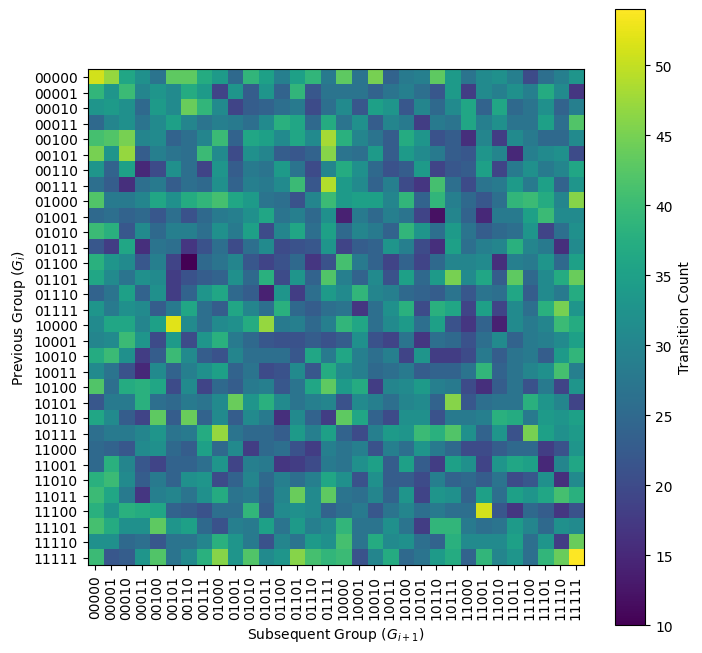

In [229]:
pre_bit_grp, post_bit_grp = prevspost_bit_grp(bitstream, 5)
plot_transition_matrix(pre_bit_grp, post_bit_grp)
print(sum(bit_list)/len(bit_list))

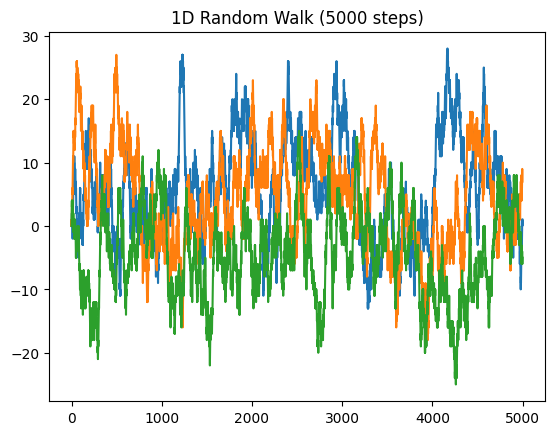

In [163]:
# random_walk_plot_1d(bit_list)
bitlength = 5000
for i in range(3):
    random_walk_plot_1d(bit_list[i*bitlength:(i+1)*bitlength])

Total No bits: 298000
Probability of generated bits: 0.5000


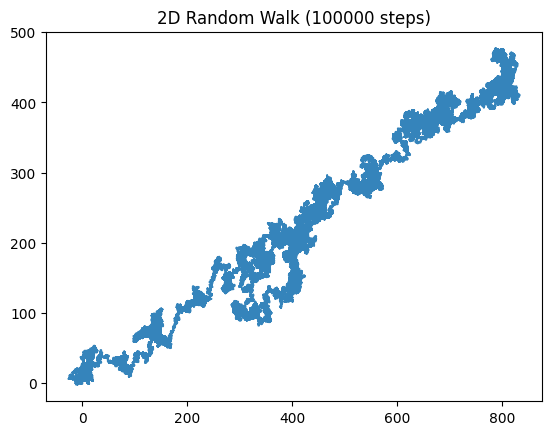

In [9]:
# random walk plot
bitstream = data_read_bin(folder+file_name1)[1000:] + data_read_bin(folder+file_name2)[1000:] 
bit_list = [int(b) for b in bitstream]
find_Prob(bitstream)
steps = 100000
# random_walk_plot_1d(bit_list)
for i in range(1):
    if (i == 2 or i == 5): continue
    random_walk_plot_2d(bit_list[i*2*steps:(i+1)*2*steps])
# plt.xlim([-100, 100])
# plt.ylim([-100, 100])

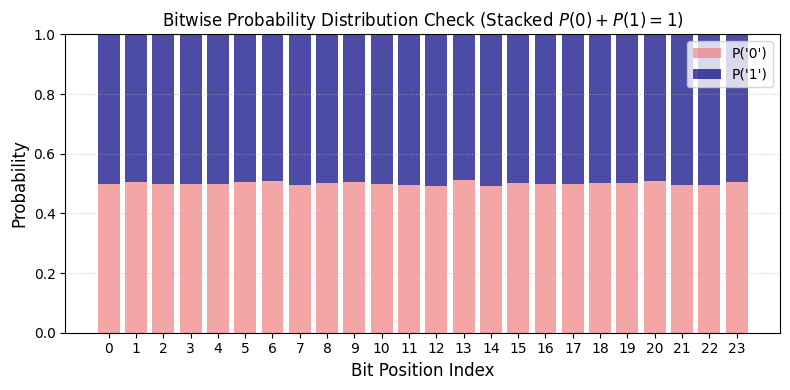

In [10]:
pre, post = prevspost_bit_grp(bitstream, 24)
trng = pre + post
bitwise_prob = bitwise_bining(trng)
plot_probability_bias(bitwise_prob)

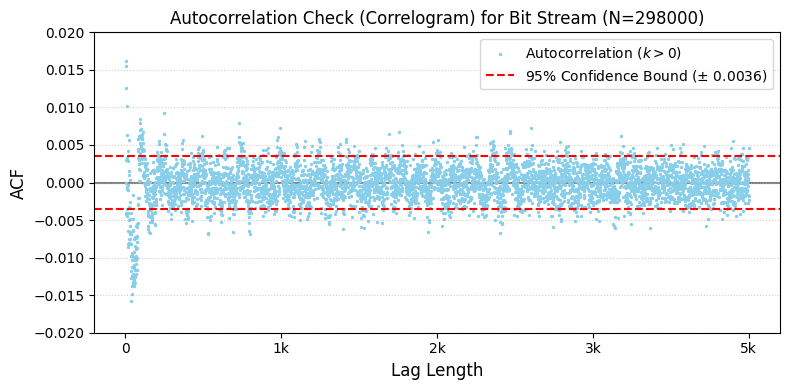

In [10]:
plot_autocorrelation_check(bitstream, max_lag=5000)

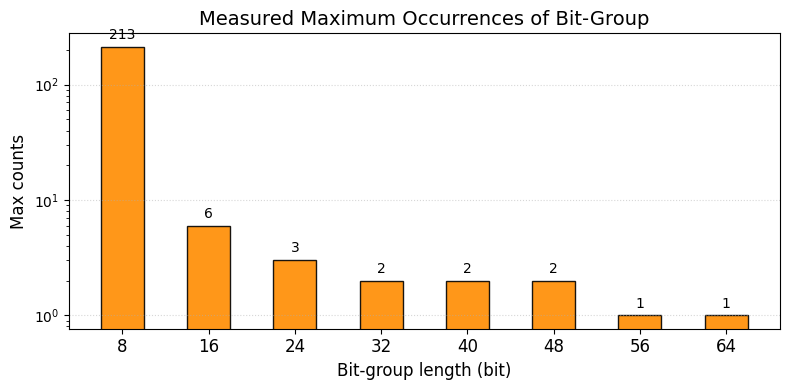

In [12]:
plot_max_bit_group_occurrences(bitstream, [8, 16, 24, 32, 40, 48, 56, 64])

In [ ]:
file_name = 'bitstream_2_4_25.txt'
bitstream = data_read_bin(folder+file_name)
bit_list = [int(b) for b in bitstream]
# covert to 0.5 probabilty bitstream using Von Neumann Extractor
def Von_Neumann_Extractor(bitstream):
    n = int(len(bitstream)/2)  # Number of steps
    bitstream_new = []
    for i in range(1,n):
        bit0 = bitstream[2*i]
        bit1 = bitstream[2*i-1]
        val = 2*bit1 + bit0
        if val == 1:
            bitstream_new.append(1)
        elif val == 2:
            bitstream_new.append(0)
    
    print("lenght of bitstream = ", len(bitstream_new))
    print("Probability of bitstream = ", sum(bitstream_new)/len(bitstream_new))
    return bitstream_new

bitstream_new = Von_Neumann_Extractor(bit_list)

lenght of bitstream =  101452
Probability of bitstream =  0.4988763158932303
